In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [74]:
# 1. UPLOAD AND PREPARE DATA
print(" Please upload 'Chocolate Sales.csv':")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

 Please upload 'Chocolate Sales.csv':


Saving Dataset Sales.csv to Dataset Sales (4).csv


In [75]:
# Load and DOUBLE the dataset for better results
df_raw = pd.read_csv(filename)
df = pd.concat([df_raw, df_raw], ignore_index=True)

In [76]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [77]:
df.tail()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
2183,Karlen McCaffrey,Australia,Spicy Special Slims,17-May-22,"$4,410",323
2184,Jehu Rudeforth,USA,White Choc,07-Jun-22,"$6,559",119
2185,Ches Bonnell,Canada,Organic Choco Syrup,26-Jul-22,$574,217
2186,Dotty Strutley,India,Eclairs,28-Jul-22,"$2,086",384
2187,Karlen McCaffrey,India,70% Dark Bites,23-May-22,"$5,075",344


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2188 entries, 0 to 2187
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   2188 non-null   object
 1   Country        2188 non-null   object
 2   Product        2188 non-null   object
 3   Date           2188 non-null   object
 4   Amount         2188 non-null   object
 5   Boxes Shipped  2188 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 102.7+ KB


In [79]:
# Data Cleaning
df['Amount'] = df['Amount'].str.replace('$', '').str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

sns.set(style="whitegrid")

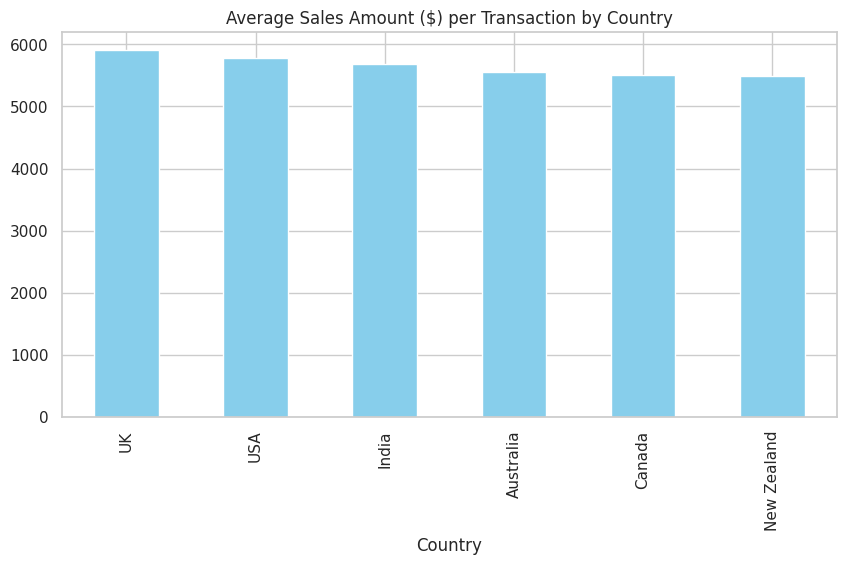

In [80]:
plt.figure(figsize=(10, 5))
df.groupby('Country')['Amount'].mean().sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Average Sales Amount ($) per Transaction by Country')
plt.show()

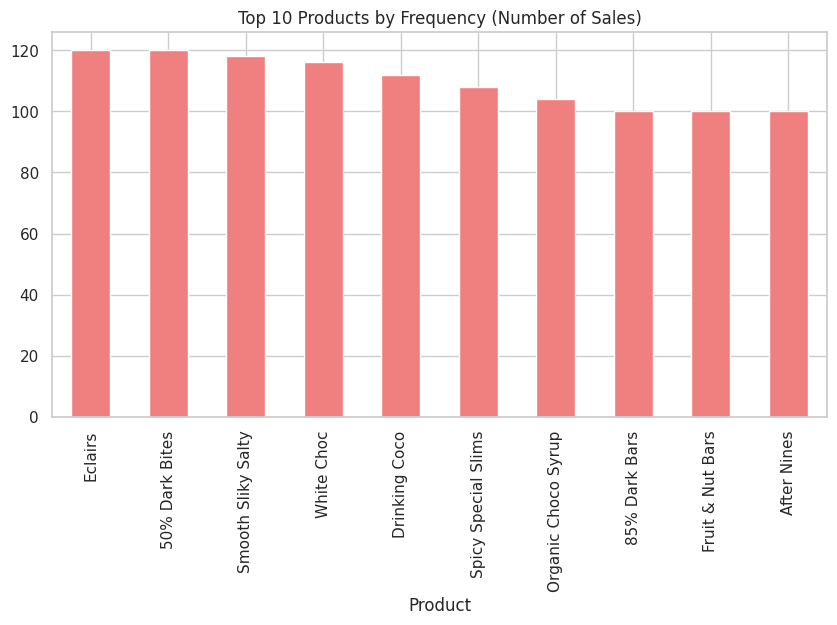

In [81]:
plt.figure(figsize=(10, 5))
df['Product'].value_counts().head(10).plot(kind='bar', color='lightcoral')
plt.title('Top 10 Products by Frequency (Number of Sales)')
plt.show()

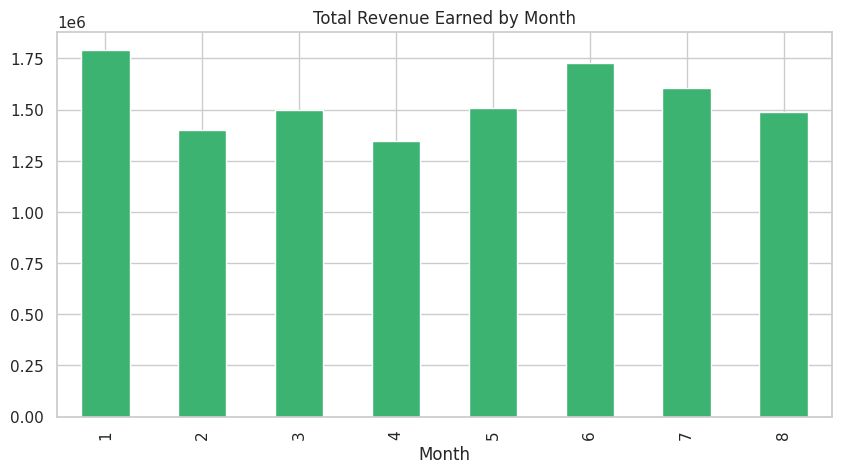

In [82]:
plt.figure(figsize=(10, 5))
df.groupby('Month')['Amount'].sum().plot(kind='bar', color='mediumseagreen')
plt.title('Total Revenue Earned by Month')
plt.show()

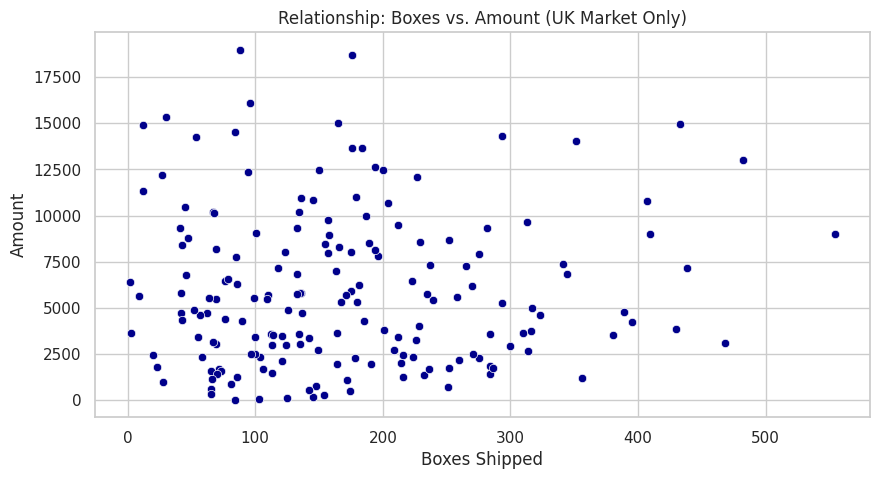

In [83]:
plt.figure(figsize=(10, 5))
uk_data = df[df['Country'] == 'UK']
sns.scatterplot(x='Boxes Shipped', y='Amount', data=uk_data, color='darkblue')
plt.title('Relationship: Boxes vs. Amount (UK Market Only)')
plt.show()

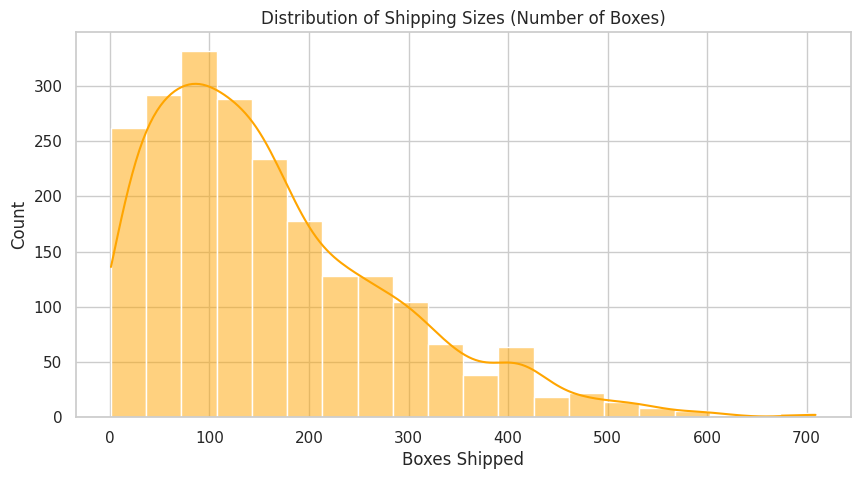

In [84]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Boxes Shipped'], bins=20, color='orange', kde=True)
plt.title('Distribution of Shipping Sizes (Number of Boxes)')
plt.show()

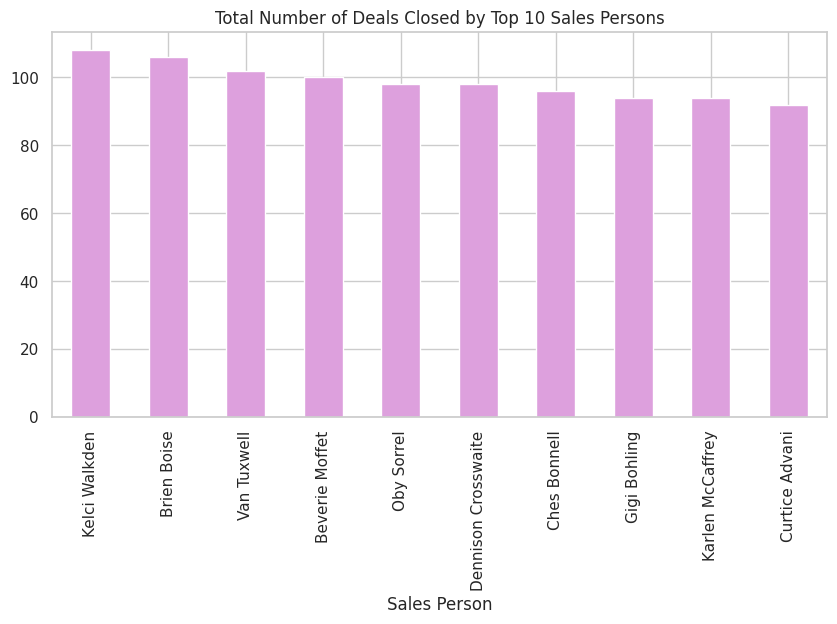

In [85]:
plt.figure(figsize=(10, 5))
df['Sales Person'].value_counts().head(10).plot(kind='bar', color='plum')
plt.title('Total Number of Deals Closed by Top 10 Sales Persons')
plt.show()

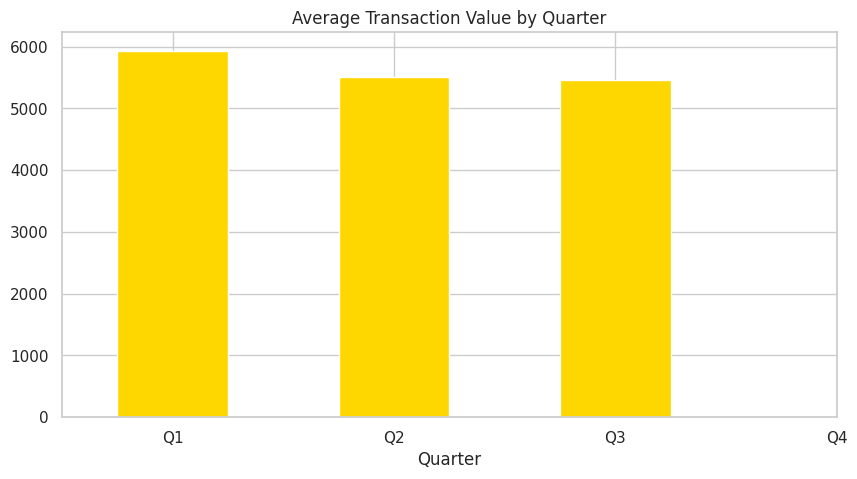

In [86]:
plt.figure(figsize=(10, 5))
df.groupby('Quarter')['Amount'].mean().plot(kind='bar', color='gold')
plt.title('Average Transaction Value by Quarter')
plt.xticks(ticks=[0,1,2,3], labels=['Q1', 'Q2', 'Q3', 'Q4'], rotation=0)
plt.show()

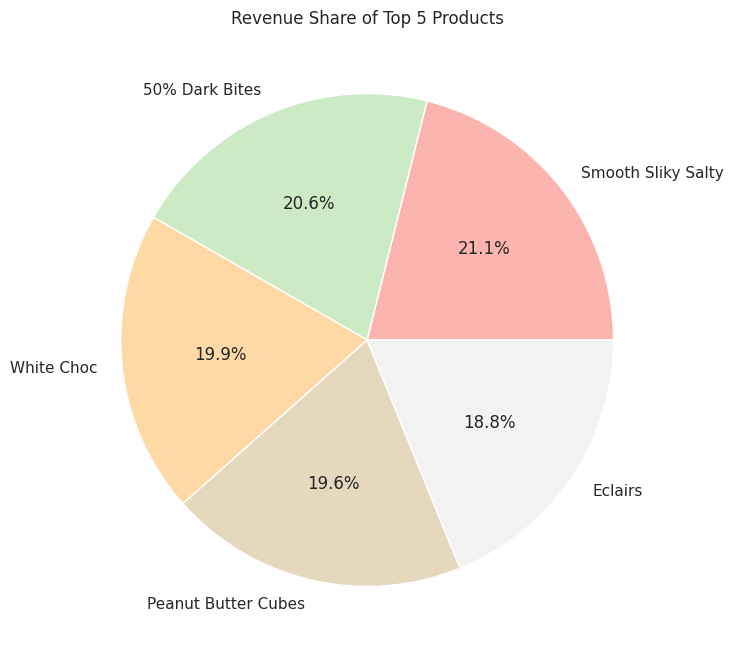

In [87]:
plt.figure(figsize=(8, 8))
df.groupby('Product')['Amount'].sum().nlargest(5).plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Revenue Share of Top 5 Products')
plt.ylabel('')
plt.show()

In [88]:
# --- FIX FOR ATTRIBUTE ERROR ---
# We convert to string first to ensure .str accessor works, then clean and convert to numeric
if 'Amount' in df.columns:
    df['Amount'] = df['Amount'].astype(str).str.replace('$', '').str.replace(',', '')
    df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
    df = df.dropna(subset=['Amount'])

# Date Features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df = df.dropna(subset=['Date'])

# Encoding categorical variables
le = LabelEncoder()
for col in ['Sales Person', 'Country', 'Product']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

In [89]:
# 2. FEATURE SELECTION
# Selecting the independent variables and the target (Amount)
features = ['Sales Person', 'Country', 'Product', 'Boxes Shipped', 'Month', 'Quarter']
X = df[features]
y = df['Amount']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Essential for SVR to work correctly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [90]:
# 3. MODEL 1: SUPPORT VECTOR REGRESSION (SVM)
svr_model = SVR(kernel='rbf', C=1000, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)
svr_pred = svr_model.predict(X_test_scaled)

# 4. MODEL 2: BAYESIAN RIDGE (Naive Bayes for Regression)
bayesian_model = BayesianRidge()
bayesian_model.fit(X_train_scaled, y_train)
bayesian_pred = bayesian_model.predict(X_test_scaled)

In [91]:
# 5. PERFORMANCE CALCULATION (MSE, MAE, R2)
results = []
for name, pred in [("SVM (SVR)", svr_pred), ("Bayesian Ridge", bayesian_pred)]:
    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'R2 Score': r2
    })
    print(f"--- {name} Results ---")
    print(f"MSE: {mse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}\n")

results_df = pd.DataFrame(results)

--- SVM (SVR) Results ---
MSE: 17485938.93
MAE: 3217.60
R2 Score: -0.0737

--- Bayesian Ridge Results ---
MSE: 16445355.54
MAE: 3244.79
R2 Score: -0.0098



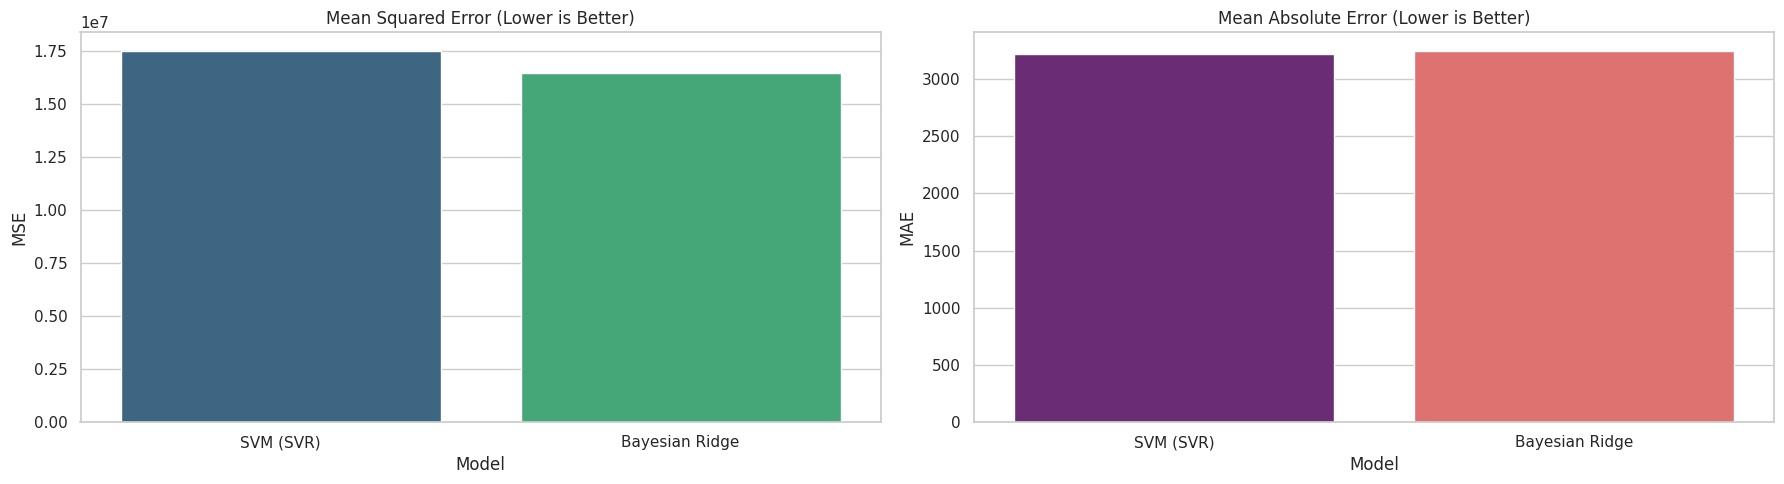

In [94]:
# 6. VISUALIZATION COMPARISON FOR ALL VALUES
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# MSE Comparison
sns.barplot(x='Model', y='MSE', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Mean Squared Error (Lower is Better)')

# MAE Comparison
sns.barplot(x='Model', y='MAE', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Mean Absolute Error (Lower is Better)')


plt.tight_layout()
plt.show()